# Zadanie 4: obliczenia ewolucyjne

Termin realizacji: 5 maja 2025

Zadanie do oddania przez MS Teams. Do oddania: kod oraz krótkie sprawozdanie w PDF (można na przykład przy użyciu `quarto render notebook.ipynb --to pdf`).

## Na 3.0

Do realizacji:

1. Zmodyfikuj przykład "iterative method" z notatnika `tsp_lazy_constraints.ipynb` z poprzednich zajęć tak, aby rozwiązywał [problem podróżującego konsumenta](https://en.wikipedia.org/wiki/Traveling_purchaser_problem). Przykładowe problemy generuje poniższa funkcja `generate_random_tpp`. Przyjmij, że wszystkie miasta muszą być odwiedzone niezależnie od tego czy dokonany tam będzie zakup czy też nie. W rozwiązaniu wypisz w którym mieście kupione będą poszczególne przedmioty oraz narysuj trasę.
2. Zmodyfikuj analogicznie kod z notatnika `tsp-genetic.ipynb` tak aby rozwiązywał ten sam problem. Porównaj wydajność (czas obliczeń i wartość funkcji kosztu) dla dziewięciu losowych problemów, po trzy dla rozmiarów (n=50, k=20), (n=50, k=50) oraz (n=100, k=100). Dobierz parametry algorytmu genetycznego tak, aby czas działania nie przekraczał w żadnym przypadku minuty.

## Na 4.0

Do realizacji:

1. Punkty z zadania na 3.0.
2. Zaimplementuj dodatkowo [krzyżowanie PMX](https://en.wikipedia.org/wiki/Crossover_(genetic_algorithm)#Partially_mapped_crossover_(PMX)) i porównaj wydajność z tym opartym o inwersję permutacji.

## Na 5.0

Do realizacji:

1. Punkty z zadania na 4.0.
2. Zmodyfikuj problem tak, aby konsument nie musiał odwiedzać miast w których niczego nie kupuje.
3. Dodaj dodatkowo do porównania zmodyfikowany dla problemu podróżującego konsumenta przykład "lazy constraints" z notatnika `tsp_lazy_constraints.ipynb`.


In [1]:
using JuMP
import GLPK
import Random
import Plots

function generate_random_tpp(n, k; random_seed = 1)
    rng = Random.MersenneTwister(random_seed)
    # distance matrix
    X = 100 * rand(rng, n)
    Y = 100 * rand(rng, n)
    d = [sqrt((X[i] - X[j])^2 + (Y[i] - Y[j])^2) for i in 1:n, j in 1:n]

    cost_item_city = 50 .+ 100 .* rand(rng, k, n) # cost_item_city[num_item, num_city]

    return X, Y, d, cost_item_city
end

n = 100
k = 100
X, Y, d, cost_item_city = generate_random_tpp(n, k)
cost_item_city

100×100 Matrix{Float64}:
 109.564   111.42     94.9661  149.826   …  136.784    79.4741   64.0847
 131.923   130.456   121.69     64.8528      89.1607  103.712    64.7647
 141.37     69.3657  108.387   124.077      126.438    83.1389   95.4242
  91.4897   58.4942   95.5106  128.022      139.961   147.012   101.345
  65.4295  128.264    53.2912   89.1547      57.6484   80.7694   73.4865
 144.274   138.069   103.702    50.7352  …  149.221    71.4166  103.501
 113.551    87.5135   52.3601   50.496       79.4169   92.1609  100.028
 105.524   104.194   115.275    51.1225      69.7575  133.212    75.637
 125.086    51.108   115.364   122.327       57.2856  119.83     93.2142
 142.641   113.746    98.6583  128.784      100.461    73.7217   66.0422
   ⋮                                     ⋱                      
  78.2823  107.988    69.7701   56.7699     114.076   140.202   127.01
  53.3044   58.561   112.797   121.572      121.072   149.082    60.4427
  92.1189   82.9157  131.139    66.8161 

In [ ]:
function build_tpp_model(d, cost_item_city, n, k)
    model = Model(GLPK.Optimizer)
    @variable(model, x[1:n, 1:n], Bin, Symmetric)
    @variable(model, y[1:k, 1:n], Bin) # y[i, j] = 1 if item i is bought in city j else y[i, j] = 0
    @objective(model, Min, sum(d .* x) / 2 + sum(cost_item_city .* y))
    @constraint(model, [i in 1:n], sum(x[i, :]) == 2)
    @constraint(model, [i in 1:n], x[i, i] == 0)
    @constraint(model, [i in 1:k], sum(y[i, :]) == 1) # each item need to be bought once
    return model
end

function subtour(edges::Vector{Tuple{Int,Int}}, n)
    shortest_subtour, unvisited = collect(1:n), Set(collect(1:n))
    while !isempty(unvisited)
        this_cycle, neighbors = Int[], unvisited
        while !isempty(neighbors)
            current = pop!(neighbors)
            push!(this_cycle, current)
            if length(this_cycle) > 1
                pop!(unvisited, current)
            end
            neighbors =
                [j for (i, j) in edges if i == current && j in unvisited]
        end
        if length(this_cycle) < length(shortest_subtour)
            shortest_subtour = this_cycle
        end
    end
    return shortest_subtour
end

function selected_edges(x::Matrix{Float64}, n)
    return Tuple{Int,Int}[(i, j) for i in 1:n, j in 1:n if x[i, j] > 0.5]
end

function bought_items(y::Matrix{Float64}, n, k)
    return sort(Tuple{Int,Int}[(i, j) for i in 1:k, j in 1:n if y[i, j] > 0.5], by = first)
end

subtour(x::Matrix{Float64}) = subtour(selected_edges(x, size(x, 1)), size(x, 1))
subtour(x::AbstractMatrix{VariableRef}) = subtour(value.(x))

function solve_tpp(n, k)
    X, Y, d, cost_item_city = generate_random_tpp(n, k)
    iterative_model = build_tpp_model(d, cost_item_city, n, k)
    optimize!(iterative_model)
    @assert is_solved_and_feasible(iterative_model)
    time_iterated = solve_time(iterative_model)
    cycle = subtour(iterative_model[:x])
    while 1 < length(cycle) < n
        # println("Found cycle of length $(length(cycle))")
        S = [(i, j) for (i, j) in Iterators.product(cycle, cycle) if i < j]
        @constraint(
            iterative_model,
            sum(iterative_model[:x][i, j] for (i, j) in S) <= length(cycle) - 1,
        )
        optimize!(iterative_model)
        @assert is_solved_and_feasible(iterative_model)
        time_iterated += solve_time(iterative_model)
        cycle = subtour(iterative_model[:x])
    end

    obj = objective_value(iterative_model)
    return iterative_model, obj, time_iterated
end

solve_tpp (generic function with 1 method)

Found cycle of length 3
Found cycle of length 10
Found cycle of length 3
Found cycle of length 3
Item 1 is bought in city 46
Item 2 is bought in city 33
Item 3 is bought in city 41
Item 4 is bought in city 25
Item 5 is bought in city 13
Item 6 is bought in city 16
Item 7 is bought in city 16
Item 8 is bought in city 16
Item 9 is bought in city 6
Item 10 is bought in city 19
Item 11 is bought in city 2
Item 12 is bought in city 4
Item 13 is bought in city 4
Item 14 is bought in city 40
Item 15 is bought in city 25
Item 16 is bought in city 13
Item 17 is bought in city 22
Item 18 is bought in city 7
Item 19 is bought in city 14
Item 20 is bought in city 6


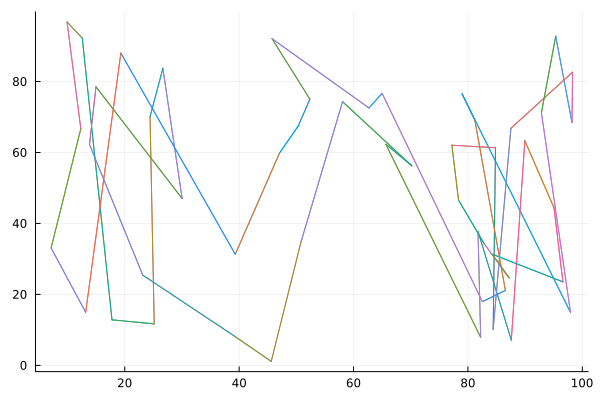

In [ ]:
function plot_tour(X, Y, x)
    plot = Plots.plot()
    for (i, j) in selected_edges(x, size(x, 1))
        Plots.plot!([X[i], X[j]], [Y[i], Y[j]]; legend = false)
    end
    return plot
end

function items_info(y::Matrix{Float64}, n, k)
    for (i, j) in bought_items(y, n, k)
        println("Item $i is bought in city $j")
    end
end


it_model, obj, time_iterated = solve_tpp(50, 20)
items_info(value.(it_model[:y]), 50, 20)
plot_tour(X, Y, value.(it_model[:x]))

In [ ]:
n1, k1 = 50, 20
n2, k2 = 50, 50
n3, k3 = 100, 100

println("n = $n1, k = $k1")
for i in 1:3
    it_model, obj, time_iterated = solve_tpp(50, 20)
    items_info(value.(it_model[:y]), 50, 20)
    plot_tour(X, Y, value.(it_model[:x]))
end

println("n = $n2, k = $k2")
for i in 1:3
    it_model, obj, time_iterated = solve_tpp(50, 50)
    items_info(value.(it_model[:y]), 50, 50)
    plot_tour(X, Y, value.(it_model[:x]))
end

println("n = $n3, k = $k3")
for i in 1:3
    it_model, obj, time_iterated = solve_tpp(100, 100)
    items_info(value.(it_model[:y]), 100, 100)
    plot_tour(X, Y, value.(it_model[:x]))
end

# todo datframe

n = 50, k = 20
Found cycle of length 3
Found cycle of length 10
Found cycle of length 3
Found cycle of length 3
Item 1 is bought in city 46
Item 2 is bought in city 33
Item 3 is bought in city 41
Item 4 is bought in city 25
Item 5 is bought in city 13
Item 6 is bought in city 16
Item 7 is bought in city 16
Item 8 is bought in city 16
Item 9 is bought in city 6
Item 10 is bought in city 19
Item 11 is bought in city 2
Item 12 is bought in city 4
Item 13 is bought in city 4
Item 14 is bought in city 40
Item 15 is bought in city 25
Item 16 is bought in city 13
Item 17 is bought in city 22
Item 18 is bought in city 7
Item 19 is bought in city 14
Item 20 is bought in city 6
Found cycle of length 3
Found cycle of length 10
Found cycle of length 3
Found cycle of length 3
Item 1 is bought in city 46
Item 2 is bought in city 33
Item 3 is bought in city 41
Item 4 is bought in city 25
Item 5 is bought in city 13
Item 6 is bought in city 16
Item 7 is bought in city 16
Item 8 is bought in city 16
It